In [1]:
import sys
from pathlib import Path
base_path = Path('..')
sys.path.insert(0, str(base_path))

In [2]:
import warnings
warnings.filterwarnings(action='ignore')

import matplotlib.pyplot as plt
import numpy as np

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score  

from erasers import MUtE

# Minimal Example

A minimal example to show how to use the method on a simple 2 blobs dataset. 

In [3]:
# Create a toy dataset
x, z = make_blobs(n_samples=2000, centers=2, n_features=2, random_state=42)
x = x - x.mean(axis=0) # center the data
x, x_test, z, z_test = train_test_split(x, z, test_size=0.2, random_state=42)

# Erasure (MUtE)
erasure_model = MUtE(nsteps=50) 
x_ = erasure_model.fit_transform(x,z) # learn the erasure function (including the concept classifier for routing)
x_test_ = erasure_model.transform(x_test)

# # Optimal Erasure (MUtE*)
# erasure_model = MUtE(nsteps=50, optimal_erasure=True) 
# erasure_model.fit(x,z) # learn the erasure function 
# x_ = erasure_model.transform(x, z) 
# x_test_ = erasure_model.transform(x_test, z_test)

# Counterfactual generation
z_cf = 1 - z
x_cf = erasure_model.inverse_transform(x_, z_cf)

# Evaluation (probing accuracy)
clf = MLPClassifier(random_state=42, early_stopping=True).fit(x,z)
print(f"Probing accuracy before erasure: {accuracy_score(z_test, clf.predict(x_test)):.4f}")
clf_ = MLPClassifier(random_state=42, early_stopping=True).fit(x_, z)
print(f"Probing accuracy after erasure: {accuracy_score(z_test, clf_.predict(x_test_)):.4f}")



Class predictor trained with accuracy (on train set): 0.99875


Iteration 50/50 complete.: 100%|██████████| 50/50 [00:00<00:00, 140.62it/s]


Probing accuracy before erasure: 1.0000
Probing accuracy after erasure: 0.4725


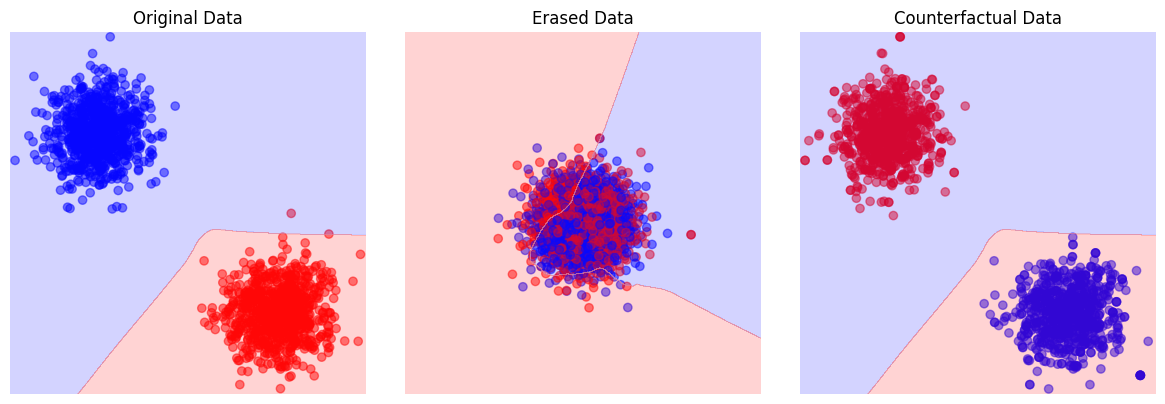

In [4]:
def plot_data(x, x_, x_cf, z, clf, clf_, colormap='bwr'):
    # Let's plot the 3 previous plots in a single figure with 3 subplots aligned horizontally and with the same size 3,4
    plt.figure(figsize=(12,4))

    # Calculate the common limits for all subplots
    all_data = [x, x_, x_cf]
    x_eps, y_eps = 0.2, 0.2
    x_min_all = min([d[:,0].min() for d in all_data]) - x_eps
    x_max_all = max([d[:,0].max() for d in all_data]) + x_eps
    y_min_all = min([d[:,1].min() for d in all_data]) - y_eps
    y_max_all = max([d[:,1].max() for d in all_data]) + y_eps

    plt.subplot(1, 3, 1)
    plt.scatter(x[:,0], x[:,1], c=z, cmap=colormap, alpha=0.5)
    plt.title("Original Data")

    plt.subplot(1, 3, 2)
    plt.scatter(x_[:,0], x_[:,1], c=z, cmap=colormap, alpha=0.5)
    plt.title("Erased Data")

    plt.subplot(1, 3, 3)
    plt.scatter(x_cf[:,0], x_cf[:,1], c=z, cmap=colormap, alpha=0.5)
    plt.title("Counterfactual Data")

    # draw the decision boundary of the classifier
    xx, yy = np.meshgrid(np.linspace(x_min_all, x_max_all, 1000), np.linspace(y_min_all, y_max_all, 1000))
    if clf is not None:
        for i in [1,3]:
            plt.subplot(1, 3, i)
            Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
            Z = Z.reshape(xx.shape) 
            plt.contourf(xx, yy, Z, alpha=0.2, cmap=colormap)
    plt.subplot(1, 3, 2)
    Z = clf_.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.2, cmap=colormap)

    # Apply consistent limits and formatting to each subplot
    for i in range(1, 4):
        plt.subplot(1, 3, i)    
        plt.xlim(x_min_all, x_max_all)
        plt.ylim(y_min_all, y_max_all)
        plt.gca().set_aspect('equal')
        plt.xticks([])
        plt.yticks([])

        # remove the black border around the plot
        plt.gca().spines['top'].set_visible(False)
        plt.gca().spines['right'].set_visible(False)
        plt.gca().spines['bottom'].set_visible(False)  
        plt.gca().spines['left'].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_data(x, x_, x_cf, z, clf, clf_)

A minimal example to show how to use the method on a simple 4 blobs dataset. 

Class predictor trained with accuracy (on train set): 0.999375


Iteration 45/50 complete.:  76%|███████▌  | 38/50 [00:00<00:00, 185.63it/s]

Iteration 50/50 complete.: 100%|██████████| 50/50 [00:00<00:00, 184.55it/s]


Probing accuracy before erasure: 1.0000
Probing accuracy after erasure: 0.2000


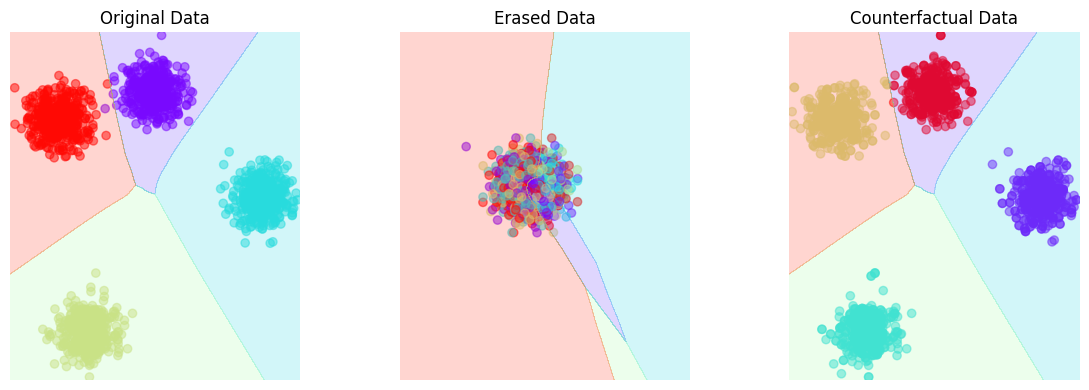

In [5]:
# Create a toy dataset
x, z = make_blobs(n_samples=2000, centers=4, n_features=2, random_state=42)
x = x - x.mean(axis=0) # center the data
x, x_test, z, z_test = train_test_split(x, z, test_size=0.2, random_state=42)

# Erasure (MUtE)
erasure_model = MUtE(nsteps=50) 
x_ = erasure_model.fit_transform(x,z) # learn the erasure function (including the concept classifier for routing)
x_test_ = erasure_model.transform(x_test)

# # Optimal Erasure (MUtE*)
# erasure_model = MUtE(nsteps=50, optimal_erasure=True) 
# erasure_model.fit(x,z) # learn the erasure function 
# x_ = erasure_model.transform(x, z) 
# x_test_ = erasure_model.transform(x_test, z_test)

# Counterfactual generation
z_cf = (z+1) % 4
x_cf = erasure_model.inverse_transform(x_, z_cf)

# Evaluation (probing accuracy)
clf = MLPClassifier(random_state=42, early_stopping=True).fit(x,z)
print(f"Probing accuracy before erasure: {accuracy_score(z_test, clf.predict(x_test)):.4f}")
clf_ = MLPClassifier(random_state=42, early_stopping=True).fit(x_, z)
print(f"Probing accuracy after erasure: {accuracy_score(z_test, clf_.predict(x_test_)):.4f}")

plot_data(x, x_, x_cf, z, clf, clf_, colormap='rainbow')

# Impact of the routing classifier

The results below show that the default routing clasifier $\eta^*$  of the MUtE eraser has an accuracy of $86\%$ which, as a consequence, produces artifacts corresponding to misclassified samples.

Class predictor trained with accuracy (on train set): 0.866875


Iteration 3/200 complete.:   0%|          | 0/200 [00:00<?, ?it/s]

Iteration 200/200 complete.: 100%|██████████| 200/200 [00:00<00:00, 305.78it/s]


Probing accuracy after erasure: 0.4800


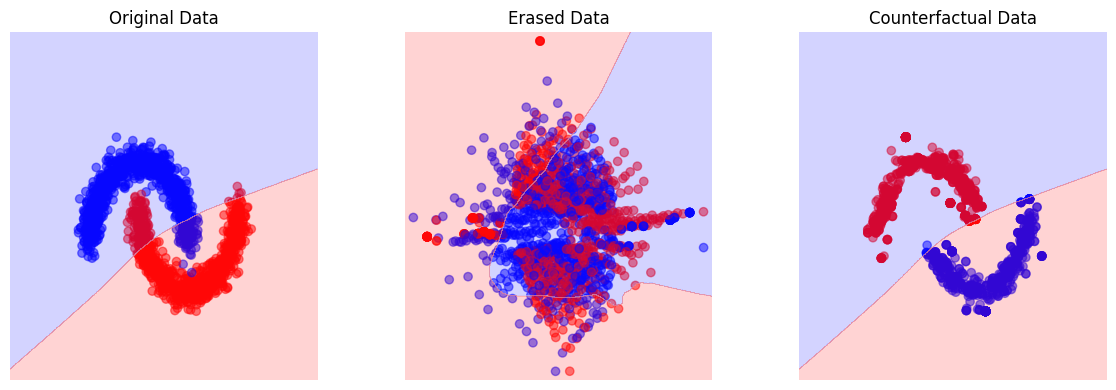

In [6]:
from sklearn.datasets import make_moons

# Create a toy dataset
x, z = make_moons(n_samples=2000, noise=0.1, random_state=42)
x = x - x.mean(axis=0) # center the data
# whiten the array x to have unit variance
x = (x - x.mean(axis=0)) / x.std(axis=0)
x, x_test, z, z_test = train_test_split(x, z, test_size=0.2, random_state=42)

# Erasure (MUtE)
erasure_model = MUtE(nsteps=200) 
x_ = erasure_model.fit_transform(x,z) # learn the erasure function (including the concept classifier for routing)
x_test_ = erasure_model.transform(x_test)

# Counterfactual generation
z_cf = 1 - z
x_cf = erasure_model.inverse_transform(x_, z_cf)

# Evaluation (probing accuracy)
clf_ = MLPClassifier(random_state=42, early_stopping=True).fit(x_, z)
print(f"Probing accuracy after erasure: {accuracy_score(z_test, clf_.predict(x_test_)):.4f}")

plot_data(x, x_, x_cf, z, erasure_model.class_clf, clf_)

Should a perfect oracle $\eta^*$ be available at test time, one can use the theoretical MUtE* function, for which no sample is misclassified, and the routing is not noisy.

Iteration 50/50 complete.: 100%|██████████| 50/50 [00:00<00:00, 305.28it/s]


Probing accuracy after erasure: 0.4875


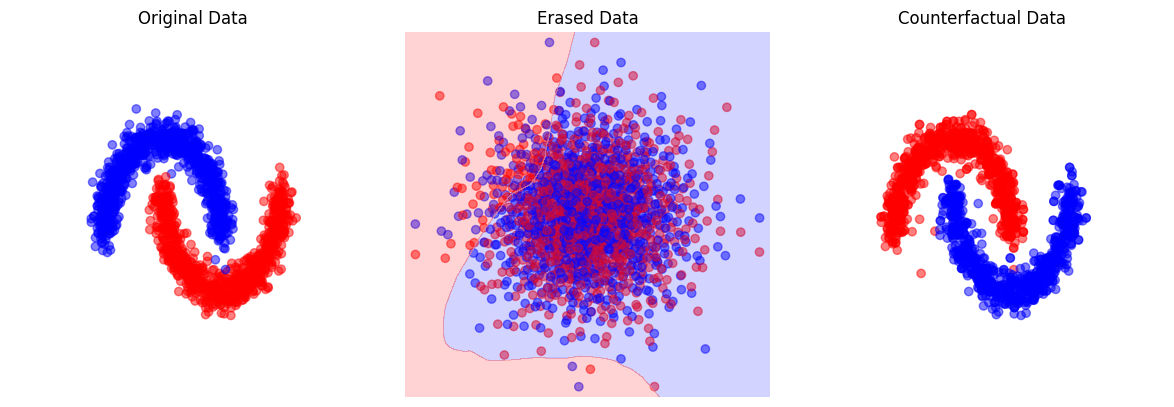

In [7]:
# Optimal Erasure (MUtE*)
erasure_model = MUtE(nsteps=50, optimal_erasure=True) 
erasure_model.fit(x,z) # learn the erasure function 
x_ = erasure_model.transform(x, z) 
x_test_ = erasure_model.transform(x_test, z_test)

# Counterfactual generation
z_cf = 1 - z
x_cf = erasure_model.inverse_transform(x_, z_cf)

# Evaluation (probing accuracy)
clf_ = MLPClassifier(random_state=42, early_stopping=True).fit(x_, z)
print(f"Probing accuracy after erasure: {accuracy_score(z_test, clf_.predict(x_test_)):.4f}")

plot_data(x, x_, x_cf, z, erasure_model.class_clf, clf_)

The MUtE class allows for setting an independently trained router by passing it as an argument when fitting the model.

Probing accuracy before erasure: 0.9975


Iteration 50/50 complete.: 100%|██████████| 50/50 [00:00<00:00, 306.23it/s]


Probing accuracy after erasure: 0.4875


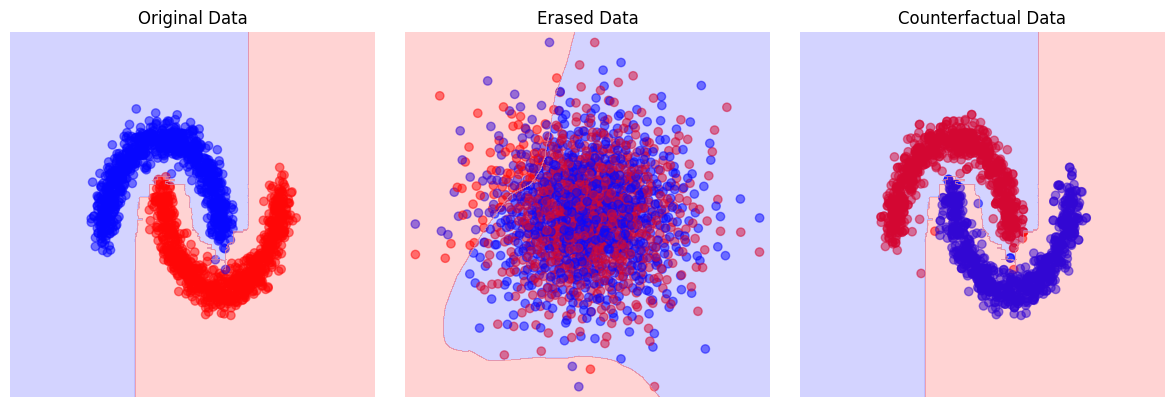

In [8]:
# Let's train a classifier on the original data (for example a random forest classifier)
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(random_state=42).fit(x,z)
print(f"Probing accuracy before erasure: {accuracy_score(z_test, clf.predict(x_test)):.4f}")

# Initialize the erasure model with optimal erasure set to False
erasure_model = MUtE(nsteps=50, optimal_erasure=False)
erasure_model.fit(x, z, class_predictor=clf) # learn the erasure function
x_ = erasure_model.transform(x) 
x_test_ = erasure_model.transform(x_test)

# Counterfactual generation
z_cf = 1 - z
x_cf = erasure_model.inverse_transform(x_, z_cf)

# Evaluation (probing accuracy)
clf_ = MLPClassifier(random_state=42, early_stopping=True).fit(x_, z)
print(f"Probing accuracy after erasure: {accuracy_score(z_test, clf_.predict(x_test_)):.4f}")

plot_data(x, x_, x_cf, z, erasure_model.class_clf, clf_)

